### Область работы 1 (библиотеки)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pandas.plotting as pd_plt
import matplotlib.colors as plt_colors
from IPython.display import display

from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV, KFold, StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.metrics import roc_curve, auc, classification_report, precision_score, ConfusionMatrixDisplay, confusion_matrix

from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA

from sklearn import svm
from sklearn.svm import SVC

### Область работы 2 (поиск  модели .... )

In [6]:
path_train = 'train.csv'

#### Посмотрим на данные

In [8]:
df = pd.read_csv(path_train)
df.tail(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1292,15.0,0.21,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7
1293,7.5,0.52,0.40,2.2,0.060,12.0,20.0,0.99474,3.26,0.64,11.8,6
1294,6.4,0.57,0.12,2.3,0.120,25.0,36.0,0.99519,3.47,0.71,11.3,7


In [9]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1295 entries, 0 to 1294
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1294 non-null   float64
 1   volatile acidity      1294 non-null   float64
 2   citric acid           1295 non-null   float64
 3   residual sugar        1295 non-null   float64
 4   chlorides             1295 non-null   float64
 5   free sulfur dioxide   1295 non-null   float64
 6   total sulfur dioxide  1295 non-null   float64
 7   density               1295 non-null   float64
 8   pH                    1294 non-null   float64
 9   sulphates             1293 non-null   float64
 10  alcohol               1295 non-null   float64
 11  quality               1295 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 121.5 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1294.000000,1294.000000,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1294.000000,1293.000000,1295.000000,1295.000000
mean,8.438872,0.500920,0.298880,2.573398,0.085467,15.362934,44.651351,0.996576,3.303648,0.678415,10.676100,5.937452
std,1.818823,0.182181,0.200443,1.366700,0.045056,10.487662,35.420622,0.001968,0.157238,0.169927,1.174136,0.955717
min,4.700000,0.120000,0.000000,0.900000,0.012000,1.000000,7.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.200000,0.360000,0.120000,1.900000,0.068000,7.000000,20.000000,0.995315,3.200000,0.570000,9.600000,5.000000
50%,8.100000,0.480000,0.310000,2.200000,0.078000,13.000000,34.000000,0.996600,3.300000,0.640000,10.500000,6.000000
75%,9.400000,0.620000,0.455000,2.600000,0.090000,21.000000,57.000000,0.997765,3.390000,0.760000,11.500000,7.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003200,4.010000,2.000000,14.900000,8.000000


In [10]:
duplicates = df[df.duplicated()]
print(df.duplicated().sum())
display(duplicates)

276


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
132,10.4,0.38,0.46,2.1,0.104,6.0,10.0,0.99664,3.12,0.65,11.8,7
139,6.7,0.28,0.28,2.4,0.012,36.0,100.0,0.99064,3.26,0.39,11.7,7
142,5.0,0.42,0.24,2.0,0.060,19.0,50.0,0.99170,3.72,0.74,14.0,8
169,13.3,0.29,0.75,2.8,0.084,23.0,43.0,0.99860,3.04,0.68,11.4,7
170,7.3,0.34,0.33,2.5,0.064,21.0,37.0,0.99520,3.35,0.77,12.1,7
...,...,...,...,...,...,...,...,...,...,...,...,...
1287,11.1,0.31,0.49,2.7,0.094,16.0,47.0,0.99860,3.12,1.02,10.6,7
1290,9.5,0.39,0.41,8.9,0.069,18.0,39.0,0.99859,3.29,0.81,10.9,7
1291,8.5,0.34,0.40,4.7,0.055,3.0,9.0,0.99738,3.38,0.66,11.6,7
1292,15.0,0.21,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7


In [11]:
duplicates[duplicates['quality'] < 7]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


<Axes: xlabel='quality', ylabel='Count'>

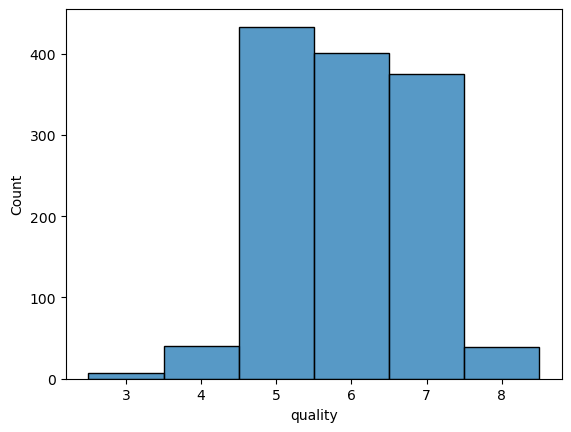

In [12]:
sns.histplot(data=df, x='quality', discrete=True)

*Есть небольшое количество пропущенных значений - самое простое и эффективное решение это удалить записи с пропущенными данными. Также есть достаточно большое количество дубликатов, которые необходимо удалить, чтобы они не вносили смещение в обучении*

**Исправим наши данные и посмотрим, что получится**

In [15]:
df = df.dropna()
df = df.drop_duplicates()

In [16]:
df['good_quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0) # задаем целевую переменную
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1015 entries, 0 to 1293
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1015 non-null   float64
 1   volatile acidity      1015 non-null   float64
 2   citric acid           1015 non-null   float64
 3   residual sugar        1015 non-null   float64
 4   chlorides             1015 non-null   float64
 5   free sulfur dioxide   1015 non-null   float64
 6   total sulfur dioxide  1015 non-null   float64
 7   density               1015 non-null   float64
 8   pH                    1015 non-null   float64
 9   sulphates             1015 non-null   float64
 10  alcohol               1015 non-null   float64
 11  quality               1015 non-null   int64  
 12  good_quality          1015 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 111.0 KB


None

<Axes: xlabel='quality', ylabel='Count'>

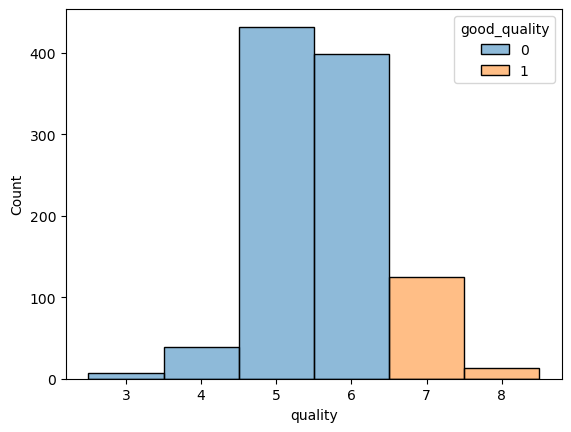

In [17]:
sns.histplot(data = df, x='quality', discrete=True, hue='good_quality')

*Оказалось, что много дубликатов было для вин высокого качества. Имеем явный дисбаланс классов*

In [19]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'good_quality'],
      dtype='object')

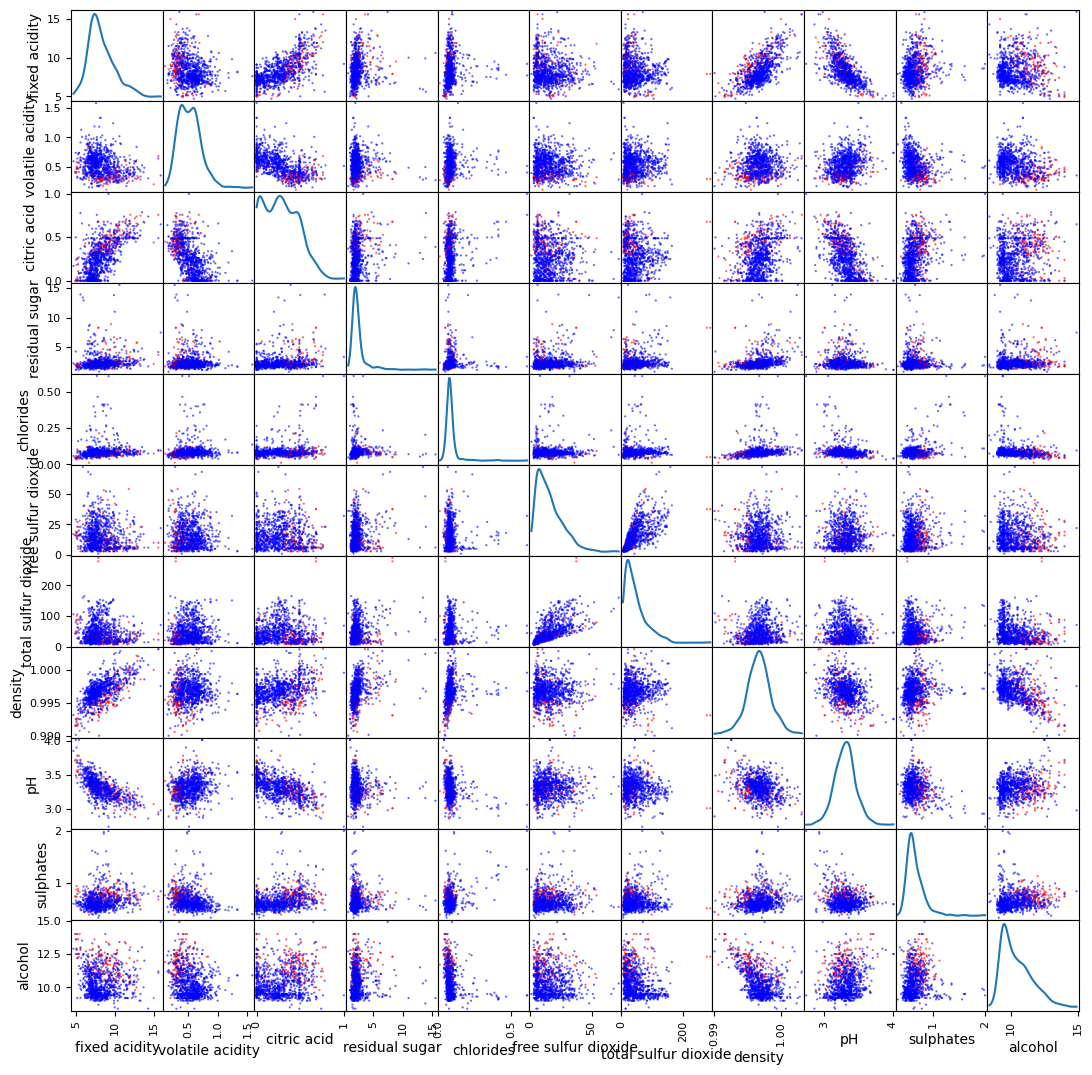

In [20]:
pd_plt.scatter_matrix(df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']],  #данные 
                     c=pd.factorize(df['good_quality'])[0],
                     alpha=0.6, 
                     s=10, 
                     figsize=(13, 13), 
                     diagonal='kde', 
                     cmap=plt_colors.ListedColormap(['blue','red'])
                    )
plt.show()

*Видим, что некоторые признаки коррелируют между собой, как например alcohol и density. Попробуем как-то это исправить*

Подготовим переменные для работы

In [23]:
X = df.drop(['quality', 'good_quality'], axis=1)
y = df['good_quality'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3)

#### Попробуем различные модели

**Наивный байес**

In [26]:
model_gs = GaussianNB()
model_gs.fit(X_train, y_train)

# Предсказание на тестовых данных
y_pred = model_gs.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86       264
           1       0.33      0.66      0.44        41

    accuracy                           0.78       305
   macro avg       0.64      0.73      0.65       305
weighted avg       0.86      0.78      0.80       305



**Метод k ближайших соседей**

In [28]:
cv = StratifiedShuffleSplit(test_size=.3, train_size=.6, n_splits=4)
#шаблон контейнера
pipe = Pipeline([('preprocessing', MinMaxScaler()),
                 # ('pca', PCA(n_components=6)),   # не улучшает модель
                 ('classifier', KNeighborsClassifier())])

n_neighbors=[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
p=[1, 2, 3]
weights=['uniform','distance']

param_grid =[
    {'preprocessing': [MinMaxScaler(), StandardScaler(),RobustScaler()],
     'classifier': [KNeighborsClassifier()],
     'classifier__n_neighbors': n_neighbors,
     'classifier__p': p,
     'classifier__weights': weights
     }
]

grid = GridSearchCV(pipe, param_grid, cv=cv, return_train_score=True, scoring='roc_auc', n_jobs=-1)   #максимизируем по roc-auc
grid.fit(X_train,y_train)

print("----------------- Обучили и тестировали -------------------")
print("Наилучшие параметры:\n{}\n".format(grid.best_params_))
print("Средняя правильность для наилучшей модели кроссвалидации на \
                валидационных тестовых наборах: {:.6f}\n".format(grid.best_score_)) 
print("Правильность для наилучшей модели на тестовом наборе: {:.6f}\n".format(grid.score(X_test, y_test)))
gridresults = pd.DataFrame(grid.cv_results_)
display(gridresults.sort_values(["rank_test_score"]).T)

----------------- Обучили и тестировали -------------------
Наилучшие параметры:
{'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 42, 'classifier__p': 2, 'classifier__weights': 'distance', 'preprocessing': MinMaxScaler()}

Средняя правильность для наилучшей модели кроссвалидации на                 валидационных тестовых наборах: 0.878748

Правильность для наилучшей модели на тестовом наборе: 0.836105



,63,81,99,117,135,69,153,45,87,171,...,140,176,68,122,8,158,26,50,14,32
mean_fit_time,0.006739,0.00649,0.008863,0.014959,0.006861,0.006238,0.006979,0.009971,0.006367,0.011098,...,0.028809,0.00911,0.00886,0.020086,0.01122,0.020694,0.014346,0.009358,0.013724,0.010606
std_fit_time,0.001748,0.00093,0.004484,0.014418,0.001026,0.001029,0.000001,0.005184,0.001244,0.008565,...,0.029005,0.000413,0.000962,0.010718,0.002272,0.018025,0.003554,0.000739,0.004261,0.00283
mean_score_time,0.014231,0.01186,0.021094,0.014959,0.015344,0.066239,0.021705,0.018081,0.087209,0.013852,...,0.095318,0.084343,0.067868,0.093095,0.013464,0.086021,0.022196,0.078359,0.096582,0.092201
std_score_time,0.00284,0.000817,0.007661,0.002116,0.002665,0.005282,0.017184,0.011448,0.021668,0.001871,...,0.006378,0.016613,0.003662,0.015772,0.002285,0.02083,0.007126,0.010841,0.016061,0.01777
param_classifier,KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),...,KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier(),KNeighborsClassifier()
param_classifier__n_neighbors,42,43,44,45,46,42,47,41,43,48,...,46,48,42,45,39,47,40,41,39,40
param_classifier__p,2,2,2,2,2,3,2,2,3,2,...,3,3,3,3,2,3,2,3,3,3
param_classifier__weights,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,...,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform,uniform
param_preprocessing,MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),...,RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler()
params,"{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...",...,"{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi...","{'classifier': KNeighborsClassifier(), 'classi..."


In [29]:
grid.best_params_

{'classifier': KNeighborsClassifier(),
 'classifier__n_neighbors': 42,
 'classifier__p': 2,
 'classifier__weights': 'distance',
 'preprocessing': MinMaxScaler()}

In [30]:
model = Pipeline([('preprocessing', StandardScaler()), 
                 ('classifier', KNeighborsClassifier(n_neighbors = 48, p = 1, weights = 'distance', n_jobs=-1))])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing', StandardScaler()),
                ('classifier',
                 KNeighborsClassifier(n_jobs=-1, n_neighbors=48, p=1,
                                      weights='distance'))])

In [31]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

1.0
0.8721311475409836


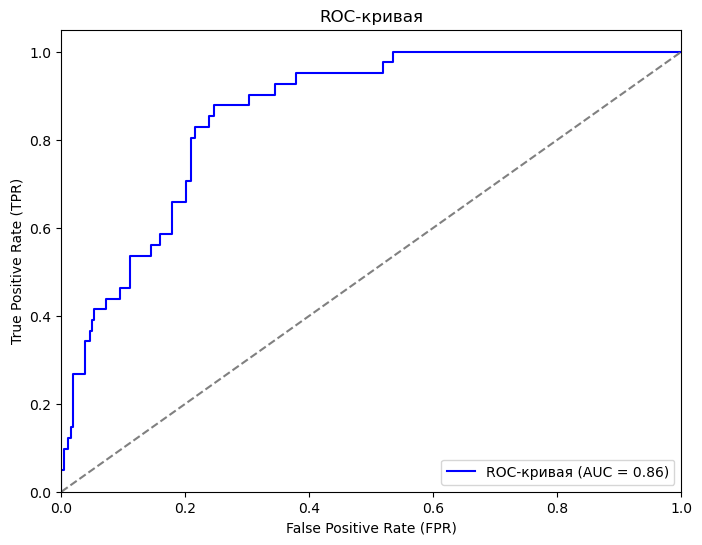

In [32]:
y_prob = model.predict_proba(X_test)[:, 1]  # вероятности для 1 класса

fpr, tpr, thresholds = roc_curve(y_test, y_prob)  # построение ROC-кривой 
roc_auc = auc(fpr, tpr)   # вычисление AUC

#Визуализация
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')   # линия случайных предсказаний
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.show()

In [33]:
y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred, pos_label=1)
print(f'Precision для класса "хорошее вино": {precision:.4f}')
print(classification_report(y_test, y_pred))

Precision для класса "хорошее вино": 0.5833
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       264
           1       0.58      0.17      0.26        41

    accuracy                           0.87       305
   macro avg       0.73      0.58      0.60       305
weighted avg       0.84      0.87      0.84       305



In [34]:
y_prob = model.predict_proba(X_test)[:, 1]

#Изменение порога
threshold = 0.52
y_pred_thres = (y_prob >= threshold).astype(int)

#Оценка Precision при новом пороге
precision_threshold = precision_score(y_test, y_pred_thres, pos_label=1)
print(classification_report(y_test, y_pred_thres))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       264
           1       0.56      0.12      0.20        41

    accuracy                           0.87       305
   macro avg       0.72      0.55      0.56       305
weighted avg       0.83      0.87      0.83       305



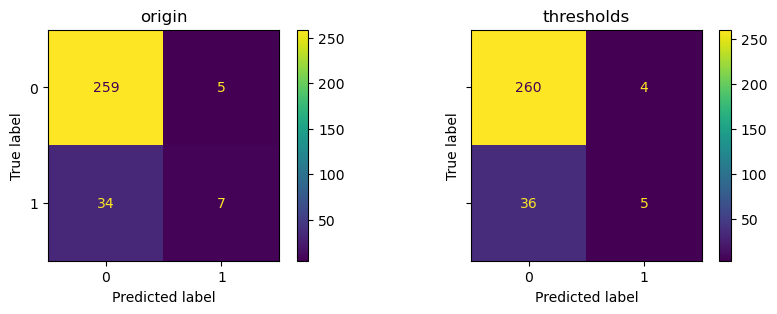

In [35]:
matrix_1=confusion_matrix(y_test,y_pred)
matrix_threshold = confusion_matrix(y_test, y_pred_thres)
fig, [ax1, ax2] = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10,3))

ConfusionMatrixDisplay(matrix_1).plot(ax = ax1);
ax1.title.set_text("origin")
ConfusionMatrixDisplay(matrix_threshold).plot(ax = ax2);
ax2.title.set_text("thresholds")
plt.show()

**Попробуем настроить параметры логистической регрессии**

In [37]:
pipe = Pipeline([('preprocessing', MinMaxScaler()), 
                 ('clf',           LogisticRegression(max_iter=1000, class_weight='balanced', penalty='l2', C=4))])

cv = StratifiedShuffleSplit(test_size = .3, train_size = .6, n_splits = 5)
scaling = [ MinMaxScaler(), StandardScaler(),RobustScaler(), Normalizer()]

param_grid =[
    {'preprocessing': scaling,'clf__penalty': ['l2'], 
         'clf__solver': ['newton-cg' ,'lbfgs', 'liblinear', 'sag', 'saga']},
    {'preprocessing': scaling,'clf__penalty': ['l1'], 
         'clf__solver': ['liblinear']},
    {'preprocessing': scaling,'clf__penalty': [None], 
         'clf__solver': ['lbfgs','newton-cg']}
    ]

grid = GridSearchCV(pipe, param_grid, cv = cv, return_train_score = True, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
grid  

GridSearchCV(cv=StratifiedShuffleSplit(n_splits=5, random_state=None, test_size=0.3,
            train_size=0.6),
             estimator=Pipeline(steps=[('preprocessing', MinMaxScaler()),
                                       ('clf',
                                        LogisticRegression(C=4,
                                                           class_weight='balanced',
                                                           max_iter=1000))]),
             n_jobs=-1,
             param_grid=[{'clf__penalty': ['l2'],
                          'clf__solver': ['newton-cg', 'lbfgs', 'liblinear',
                                          'sag', 'saga'],
                          'preprocessing'...Scaler(),
                                            RobustScaler(), Normalizer()]},
                         {'clf__penalty': ['l1'], 'clf__solver': ['liblinear'],
                          'preprocessing': [MinMaxScaler(), StandardScaler(),
                                            RobustScaler(), Normalizer()]},
                         {'clf__penalty': [None],
                          'clf__solver': ['lbfgs', 'newton-cg'],
                          'preprocessing': [MinMaxScaler(), StandardScaler(),
                                            RobustScaler(), Normalizer()]}],
             return_train_score=True, scoring='roc_auc')

In [38]:
grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,8,0,12,16,4,18,14,10,2,6,...,21,24,31,27,23,3,19,15,7,11
mean_fit_time,0.015964,0.016962,0.020267,0.019159,0.046331,0.140506,0.077146,0.018766,0.035008,0.03005,...,0.011197,0.033727,0.021549,0.043136,0.074751,0.014282,0.017558,0.021746,0.020463,0.015563
std_fit_time,0.010716,0.003164,0.007057,0.005974,0.01529,0.041292,0.020749,0.007212,0.013198,0.009676,...,0.002419,0.018851,0.002858,0.01396,0.062498,0.003133,0.004162,0.002921,0.009937,0.009181
mean_score_time,0.00639,0.005586,0.005688,0.009278,0.005194,0.005698,0.004891,0.007584,0.005991,0.006095,...,0.010601,0.01187,0.009478,0.011781,0.011473,0.013488,0.005889,0.007091,0.007497,0.008782
std_score_time,0.002339,0.000489,0.001242,0.006618,0.000416,0.000593,0.000191,0.004762,0.000704,0.00097,...,0.006845,0.008081,0.004275,0.008188,0.008771,0.012123,0.000801,0.004697,0.003105,0.007592
param_clf__penalty,l2,l2,l2,l2,l2,l2,l2,l2,l2,l2,...,l1,None,None,None,l1,l2,l2,l2,l2,l2
param_clf__solver,liblinear,newton-cg,sag,saga,lbfgs,saga,sag,liblinear,newton-cg,lbfgs,...,liblinear,lbfgs,newton-cg,lbfgs,liblinear,newton-cg,saga,sag,lbfgs,liblinear
param_preprocessing,MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),...,StandardScaler(),MinMaxScaler(),Normalizer(),Normalizer(),Normalizer(),Normalizer(),Normalizer(),Normalizer(),Normalizer(),Normalizer()
params,"{'clf__penalty': 'l2', 'clf__solver': 'libline...","{'clf__penalty': 'l2', 'clf__solver': 'newton-...","{'clf__penalty': 'l2', 'clf__solver': 'sag', '...","{'clf__penalty': 'l2', 'clf__solver': 'saga', ...","{'clf__penalty': 'l2', 'clf__solver': 'lbfgs',...","{'clf__penalty': 'l2', 'clf__solver': 'saga', ...","{'clf__penalty': 'l2', 'clf__solver': 'sag', '...","{'clf__penalty': 'l2', 'clf__solver': 'libline...","{'clf__penalty': 'l2', 'clf__solver': 'newton-...","{'clf__penalty': 'l2', 'clf__solver': 'lbfgs',...",...,"{'clf__penalty': 'l1', 'clf__solver': 'libline...","{'clf__penalty': None, 'clf__solver': 'lbfgs',...","{'clf__penalty': None, 'clf__solver': 'newton-...","{'clf__penalty': None, 'clf__solver': 'lbfgs',...","{'clf__penalty': 'l1', 'clf__solver': 'libline...","{'clf__penalty': 'l2', 'clf__solver': 'newton-...","{'clf__penalty': 'l2', 'clf__solver': 'saga', ...","{'clf__penalty': 'l2', 'clf__solver': 'sag', '...","{'clf__penalty': 'l2', 'clf__solver': 'lbfgs',...","{'clf__penalty': 'l2', 'clf__solver': 'libline..."
split0_test_score,0.869003,0.869378,0.86919,0.86919,0.869378,0.874813,0.874813,0.874813,0.875,0.875,...,0.874063,0.875562,0.862069,0.852324,0.824963,0.736882,0.736882,0.736882,0.736882,0.738756
split1_test_score,0.836394,0.836019,0.835832,0.835832,0.836207,0.832834,0.832834,0.832646,0.832646,0.832646,...,0.830397,0.827586,0.824775,0.818966,0.81072,0.704648,0.70446,0.70446,0.704648,0.706147


In [39]:
grid.best_params_

{'clf__penalty': 'l2',
 'clf__solver': 'liblinear',
 'preprocessing': MinMaxScaler()}

In [40]:
pipe_best = make_pipeline(MinMaxScaler(), LogisticRegression(solver = 'saga', penalty = 'l2') )
pipe_best.fit(X_train,y_train)
y_pred_best = pipe_best.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       264
           1       0.69      0.27      0.39        41

    accuracy                           0.89       305
   macro avg       0.79      0.62      0.66       305
weighted avg       0.87      0.89      0.86       305



**Посмотрим, что покажет модель SVM**

In [42]:
pipe_svm = make_pipeline( MinMaxScaler(), SVC(kernel='linear', degree = 5, class_weight='balanced') )

cv = StratifiedShuffleSplit(test_size = .3, train_size = .6, n_splits = 5)

C=[0.5, 1, 2, 3, 5, 10, 20, 50]
gamma=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

param_grid =[
    {'minmaxscaler': [StandardScaler(), MinMaxScaler()], 
     'svc': [svm.SVC(kernel='linear'), svm.SVC(kernel='rbf'), svm.SVC(kernel='sigmoid')],
     'svc__C': C,
     'svc__gamma': gamma
     }
]

grid = GridSearchCV(pipe_svm, param_grid, cv=cv, return_train_score=True, n_jobs=-1)
grid.fit(X_train,y_train)
table=pd.DataFrame(grid.cv_results_)

In [43]:
table.sort_values(by='mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_minmaxscaler,param_svc,param_svc__C,param_svc__gamma,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
69,0.080589,0.007289,0.038508,0.002579,StandardScaler(),SVC(),3.0,0.5,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.892019,...,0.892958,0.004600,1,0.995305,0.988263,0.992958,0.992958,0.990610,0.992019,0.002394
75,0.097617,0.020982,0.043819,0.003224,StandardScaler(),SVC(),5.0,0.5,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.887324,...,0.890141,0.005634,2,0.997653,0.995305,0.992958,1.000000,0.995305,0.996244,0.002394
81,0.092514,0.011498,0.053496,0.008238,StandardScaler(),SVC(),10.0,0.5,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.887324,...,0.889202,0.009667,3,1.000000,0.997653,0.997653,1.000000,0.997653,0.998592,0.001150
72,0.042621,0.007303,0.040954,0.013988,StandardScaler(),SVC(),5.0,0.2,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.877934,...,0.887324,0.005939,4,0.978873,0.964789,0.969484,0.978873,0.976526,0.973709,0.005634
76,0.095224,0.020354,0.046129,0.010769,StandardScaler(),SVC(),5.0,0.6,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.882629,...,0.887324,0.008398,5,0.997653,0.995305,0.995305,1.000000,0.995305,0.996714,0.001878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.030620,0.003243,0.017855,0.011079,StandardScaler(),SVC(kernel='sigmoid'),10.0,0.3,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.760563,...,0.800000,0.020270,281,0.805164,0.800469,0.828638,0.800469,0.793427,0.805634,0.012098
119,0.031642,0.010825,0.009887,0.000488,StandardScaler(),SVC(kernel='sigmoid'),3.0,0.7,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.755869,...,0.799061,0.025783,285,0.802817,0.795775,0.816901,0.816901,0.793427,0.805164,0.010069
118,0.041010,0.012750,0.017167,0.007453,StandardScaler(),SVC(kernel='sigmoid'),3.0,0.6,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.755869,...,0.799061,0.027116,285,0.802817,0.800469,0.802817,0.800469,0.802817,0.801878,0.001150
110,0.026532,0.004173,0.010579,0.002237,StandardScaler(),SVC(kernel='sigmoid'),2.0,0.4,"{'minmaxscaler': StandardScaler(), 'svc': SVC(...",0.760563,...,0.798122,0.024305,287,0.800469,0.795775,0.812207,0.812207,0.802817,0.804695,0.006539


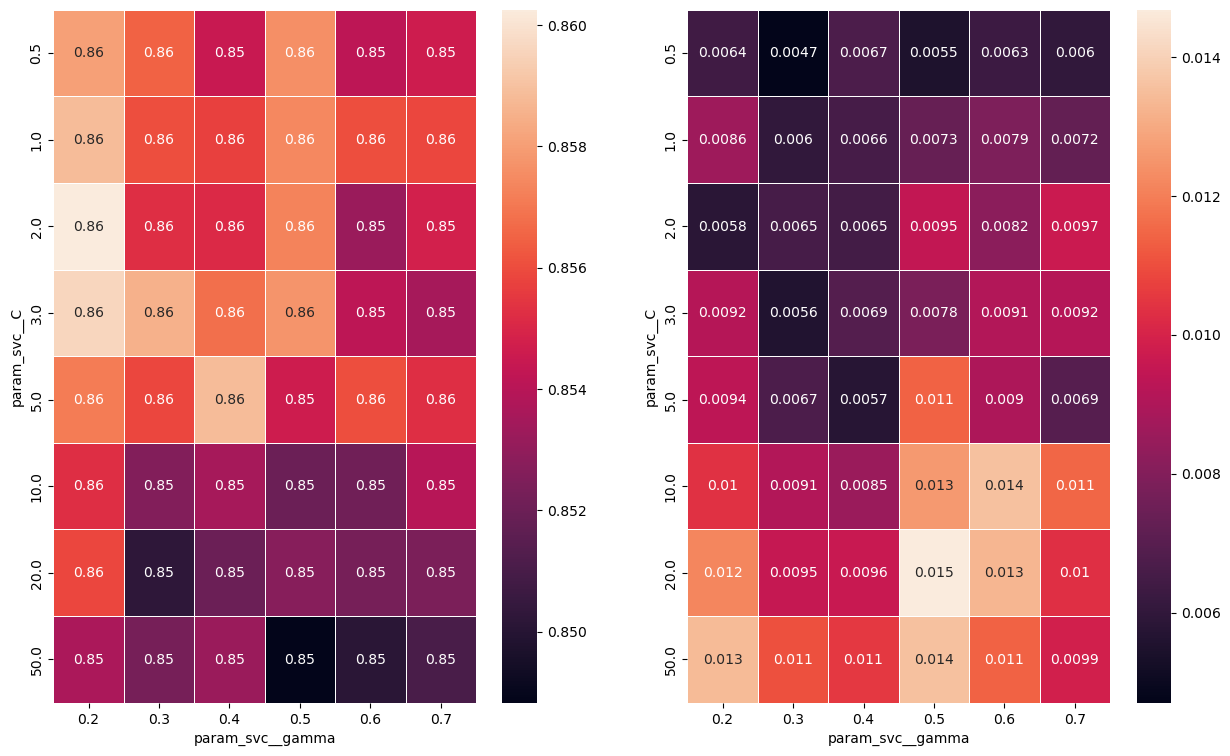

In [44]:
pv_table=table.pivot_table(index='param_svc__C',columns='param_svc__gamma',values='mean_test_score')
pv_table_std=table.pivot_table(index='param_svc__C',columns='param_svc__gamma',values='std_test_score')
f, (ax1, ax2) = plt.subplots(1, 2,figsize=(15, 9))
sns.heatmap(pv_table, annot=True, linewidths=.5, ax=ax1)
sns.heatmap(pv_table_std, annot=True, linewidths=.5, ax=ax2);

In [45]:
grid.best_params_

{'minmaxscaler': StandardScaler(),
 'svc': SVC(),
 'svc__C': 3,
 'svc__gamma': 0.5}

In [46]:
model_svm = make_pipeline(StandardScaler(), SVC(C=2, gamma=0.5) )
model_svm.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=2, gamma=0.5))])

In [47]:
print(model_svm.score(X_train, y_train))
print(model_svm.score(X_test, y_test))

0.9802816901408451
0.8721311475409836


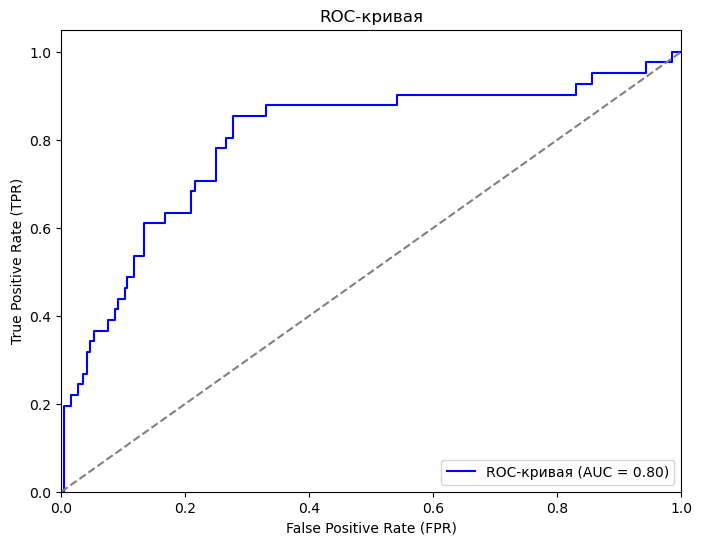

In [48]:
y_prob = model_svm.decision_function(X_test)  # вероятности для 1 класса

fpr, tpr, thresholds = roc_curve(y_test, y_prob)  # построение ROC-кривой 
roc_auc = auc(fpr, tpr)   # вычисление AUC

#Визуализация
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')   # линия случайных предсказаний
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.show()

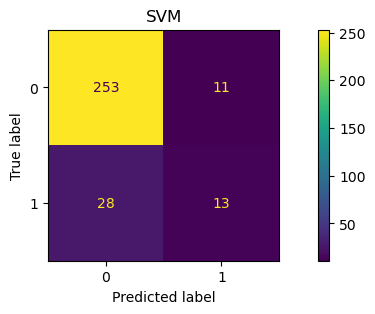

In [49]:
y_pred = model_svm.predict(X_test)
matrix_1=confusion_matrix(y_test,y_pred)

fig, ax1 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,3))

ConfusionMatrixDisplay(matrix_1).plot(ax = ax1);
ax1.title.set_text("SVM")
plt.show()

In [50]:
y_pred = model_svm.predict(X_test)
precision = precision_score(y_test, y_pred, pos_label=1)
print(f'Precision для класса "хорошее вино": {precision:.4f}')
print(classification_report(y_test, y_pred))

Precision для класса "хорошее вино": 0.5417
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       264
           1       0.54      0.32      0.40        41

    accuracy                           0.87       305
   macro avg       0.72      0.64      0.66       305
weighted avg       0.85      0.87      0.86       305



#### Вывод:

* Наивный байес выдает достаточно низкий показатель точности модели, даже после настройки *threshold*. Используем его для сравнения качества других моделей
*  Метод ближайших соседей достаточно сильно переобучается, даже после настройки гиперпараметров. Метод главных компонент, для борьбы с корреляцией фичей, не смог улучшить модель. Имеем достаточно низкий *recall*
*  Логистическая регрессия даже при настройки различных регуляризаторов (таких как *l*1, для отсева признаков) показывает не очень хорошие результаты, а *recall* вообще практически нулевой. При использовании всей выборки результаты в среднем ухудшаются
*  Модель SVM показывает достаточно высокий уровень *presion* как на тестовой, так и на всей выборке. При балансировке классов достаточно неплохо работает, достаточно стабильно и не сильно переобучается. Минус все тот же, достаточно не высокий *recall*

**Таким образом, для реализации алгоритма был выбран метод опорных векторов (SVM). Показывает наилучшие результаты. Посмотрим его работу на всей выборке**

*Метрика качества - precision для 1 класса (хорошее вино). На втором месте смотрим на recall для данного класса, т.к. объем правильных предсказаний нам также важен (как для покупателя например, зная только 1 марку точно хорошего вина, может оказаться очень проблематично найти его в магазине у дома)*

In [55]:
y_predt = model_svm.predict(X)
precision = precision_score(y, y_predt, pos_label=1)
print(f'Precision для класса "хорошее вино": {precision:.4f}')
print(classification_report(y, y_predt))

Precision для класса "хорошее вино": 0.8761
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       877
           1       0.88      0.72      0.79       138

    accuracy                           0.95      1015
   macro avg       0.92      0.85      0.88      1015
weighted avg       0.95      0.95      0.95      1015



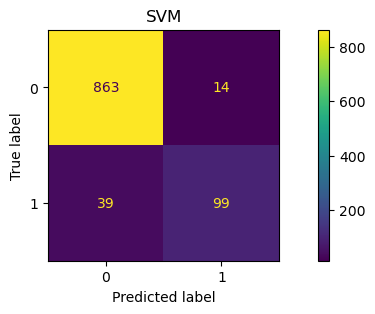

In [56]:
y_predt = model_svm.predict(X)
matrix_2=confusion_matrix(y,y_predt)

fig, ax1 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,3))

ConfusionMatrixDisplay(matrix_2).plot(ax = ax1);
ax1.title.set_text("SVM")
plt.show()